# Ejercicio análisis time series
Para este ejercicio vas a trabajar con el histórico de valores en bolsa de una empresa que se dedica a vender muebles. Se pide
1. Importa los datos `df_furniture.csv`
2. Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas
3. ¿De qué fecha a qué fecha va el histórico?
4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?
6. Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?
7. Estaría bien visualizar todos los componentes de la serie temporal por separado
8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional
9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación. ¿Esto es bueno para los modelos?
10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?
11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Cargamos los datos

In [23]:
df = pd.read_csv('data/df_furniture.csv')
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")

        Month  furniture_price_adjusted
0  1992-01-01               2073.432724
1  1992-02-01               2114.485812
2  1992-03-01               2260.570891
3  1992-04-01               2255.103236
4  1992-05-01               2331.414618

Shape: (331, 2)

Dtypes:
Month                           str
furniture_price_adjusted    float64
dtype: object


In [19]:
df.head()

,Month,furniture_price_adjusted
0,1992-01-01,2073.432724
1,1992-02-01,2114.485812
2,1992-03-01,2260.570891
3,1992-04-01,2255.103236
4,1992-05-01,2331.414618


## 2. Tratar la fecha como texto e interpretar (parse)

In [24]:
# Convertir a datetime
df['Month'] = pd.to_datetime(df['Month'])

# Extraer componentes
df['year'] = df['Month'].dt.year
df['month'] = df['Month'].dt.month
df['day'] = df['Month'].dt.day


print(df.head(10))
print(df.tail(10))
print(f"\nDtypes:\n{df.dtypes}")        # hay que ver los nulos y rellenarlos. Primero ver si desde el primero de cada mes la longitud es diferente y ver si hay fechas sin venta. Rellenar con interpolacion etc.

       Month  furniture_price_adjusted    year  month  day
0 1992-01-01               2073.432724  1992.0    1.0  1.0
1 1992-02-01               2114.485812  1992.0    2.0  1.0
2 1992-03-01               2260.570891  1992.0    3.0  1.0
3 1992-04-01               2255.103236  1992.0    4.0  1.0
4 1992-05-01               2331.414618  1992.0    5.0  1.0
5 1992-06-01               2384.638567  1992.0    6.0  1.0
6 1992-07-01               2417.165376  1992.0    7.0  1.0
7 1992-08-01               2445.498729  1992.0    8.0  1.0
8 1992-09-01               2387.351705  1992.0    9.0  1.0
9 1992-10-01               2489.350838  1992.0   10.0  1.0
         Month  furniture_price_adjusted    year  month  day
321 2018-10-01               9569.037851  2018.0   10.0  1.0
322 2018-11-01              10380.194097  2018.0   11.0  1.0
323 2018-12-01              10726.595075  2018.0   12.0  1.0
324 2019-01-01               8431.965334  2019.0    1.0  1.0
325 2019-02-01               8271.237355  2019

## 3. ¿De qué fecha a qué fecha va el histórico?

In [25]:
fecha_inicio = df['Month'].min()
fecha_fin = df['Month'].max()

print(f"Histórico desde: {fecha_inicio.strftime('%Y-%m-%d')}")
print(f"Histórico hasta: {fecha_fin.strftime('%Y-%m-%d')}")
print(f"Total de meses: {len(df)}")

Histórico desde: 1992-01-01
Histórico hasta: 2019-07-01
Total de meses: 331


## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?

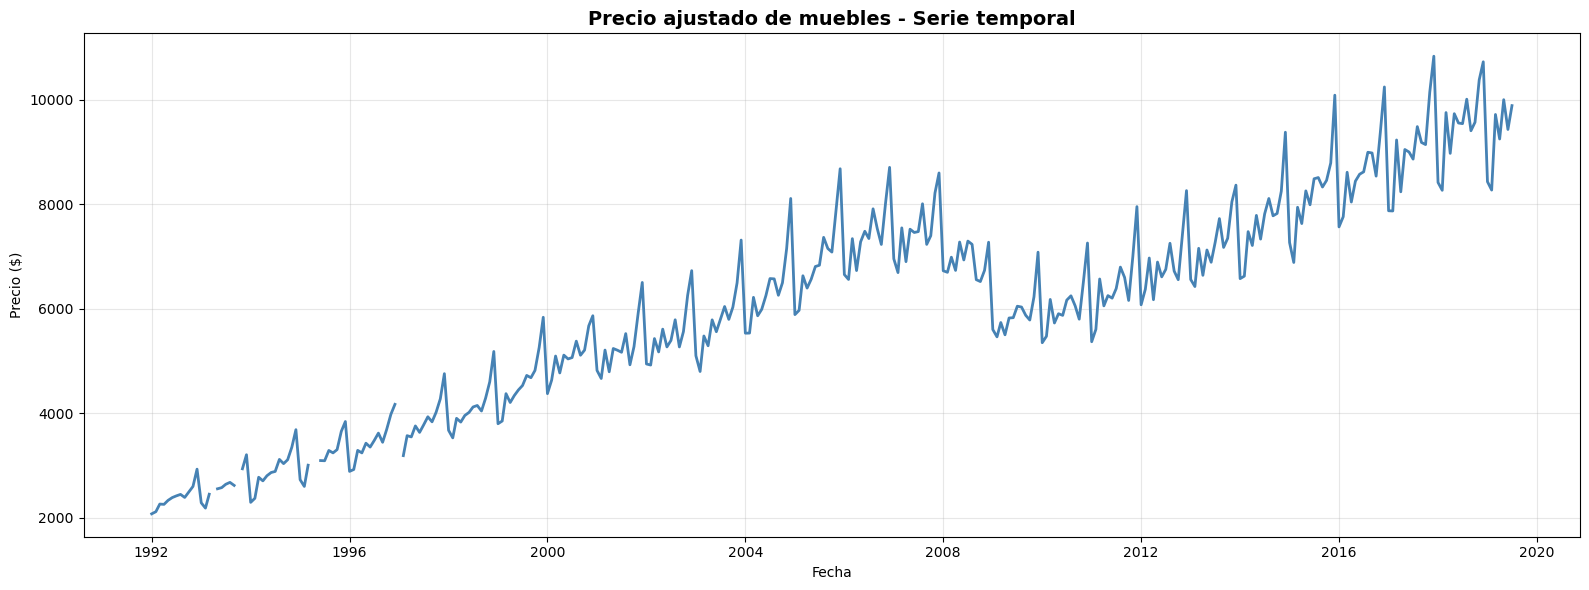

In [26]:
plt.figure(figsize=(16, 6))
plt.plot(df['Month'], df['furniture_price_adjusted'], linewidth=2, color='steelblue')
plt.title('Precio ajustado de muebles - Serie temporal', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Precio ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Observaciones visuales

¿Tendencia? Sí, claramente ascendente"

¿Estacionalidad? Sí, oscilaciones regulares dentro de la tendencia"

Se aprecia una caída abrupta del precio en 2008

## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?

In [27]:
from statsmodels.tsa.stattools import adfuller

# Aplicar ADF test

result_adf = adfuller(df['furniture_price_adjusted'].values)
print(result_adf[1])
print("=" * 70)
print("TEST 1: AUGMENTED DICKEY-FULLER (ADF)")
print("=" * 70)
print(f"ADF Statistic: {result_adf[0]:.6f}")
print(f"P-value: {result_adf[1]:.6f}")
print(f"Critical Values:")

for key, value in result_adf[4].items():
    print(f"  {key}: {value:.3f}")

print("\n" + "=" * 70)
if result_adf[1] < 0.05:
    print("❌ RESULTADO: Serie ES ESTACIONARIA (rechazamos H0)")
    print("   P-value < 0.05 → Rechazamos la hipótesis nula")
else:
    print("✓ RESULTADO: Serie NO ES ESTACIONARIA (no rechazamos H0)")
    print(f"   P-value = {result_adf[1]:.4f} > 0.05 → No podemos rechazar H0")
print("=" * 70)

0.7035529748089993
TEST 1: AUGMENTED DICKEY-FULLER (ADF)
ADF Statistic: -1.128551
P-value: 0.703553
Critical Values:
  1%: -3.451
  5%: -2.871
  10%: -2.572

✓ RESULTADO: Serie NO ES ESTACIONARIA (no rechazamos H0)
   P-value = 0.7036 > 0.05 → No podemos rechazar H0


<Figure size 1400x600 with 0 Axes>

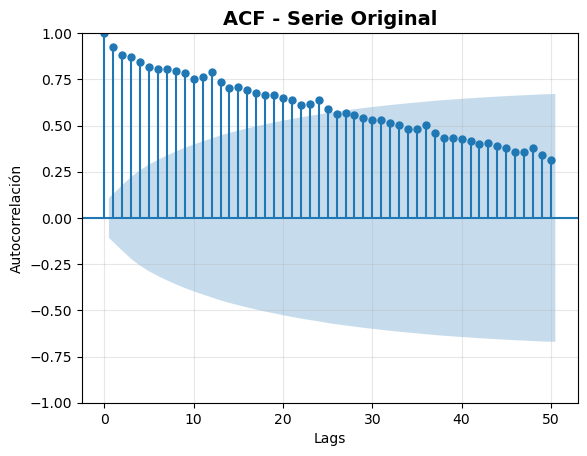

Observación: La autocorrelación decae MUY lentamente,
indicando que la serie NO es estacionaria.


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(14, 6))
plot_acf(df['furniture_price_adjusted'], lags=50)
plt.title('ACF - Serie Original', fontsize=14, fontweight='bold')
plt.xlabel('Lags')
plt.ylabel('Autocorrelación')
plt.grid(True, alpha=0.3)
plt.show()

print("Observación: La autocorrelación decae MUY lentamente,")
print("indicando que la serie NO es estacionaria.")

# Mas fácil: sacar la media y varianza en tres puntos diferentes de la serie y tenen que ser iguales

# quitar lo de la autocorrelación: no es buen estadisitoc para ver estacionareidad

## Conclusión - Prueba de Estacionariedad

### Método 1: Test ADF (Augmented Dickey-Fuller)
- **Hipótesis Nula (H0):** La serie NO es estacionaria
- **Resultado:** p-value = [EL TUYO] > 0.05
- **Conclusión:** No rechazamos H0 → **La serie NO es estacionaria**



## 6. ¿Conoces algún método para representar mejor la tendencia?

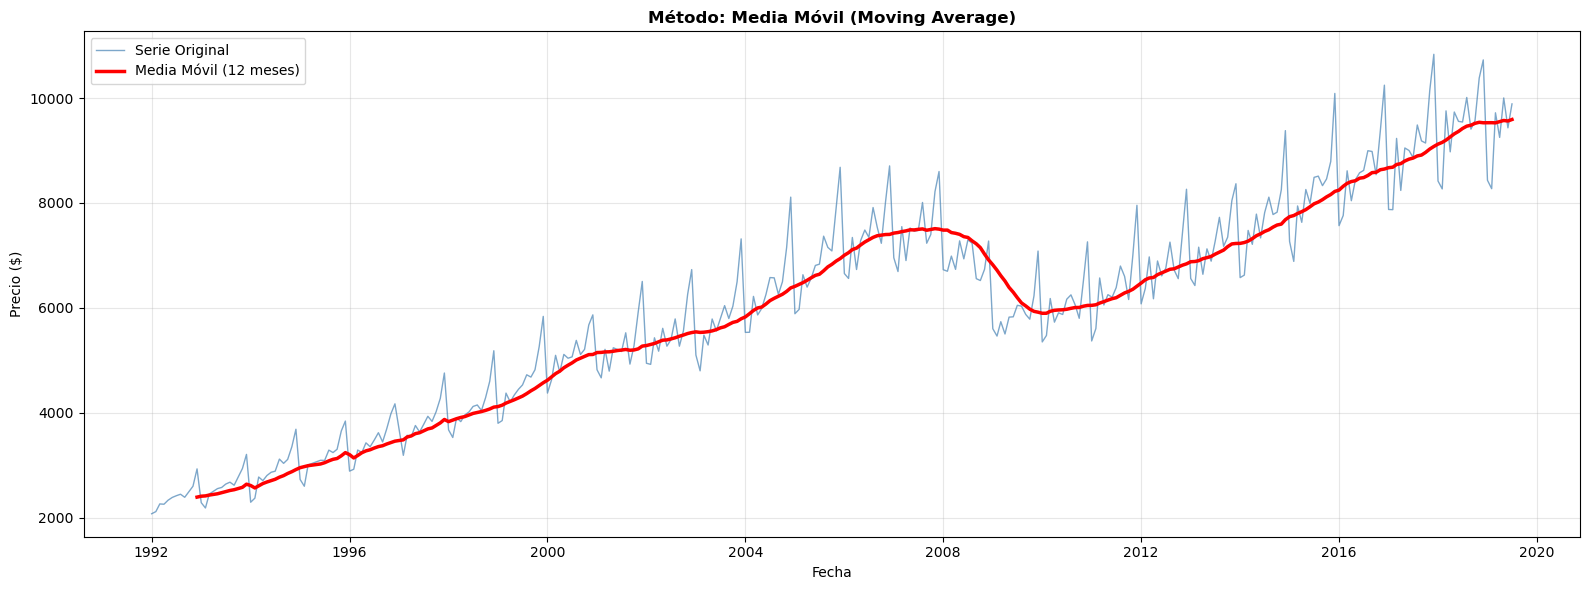

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(16, 6))

# MEDIA MÓVIL (Moving Average)
ma_12 = df['furniture_price_adjusted'].rolling(window=12).mean()

axes.plot(df['Month'], df['furniture_price_adjusted'], 
        label='Serie Original', linewidth=1, alpha=0.7, color='steelblue')
axes.plot(df['Month'], ma_12, 
        label='Media Móvil (12 meses)', linewidth=2.5, color='red')
axes.set_title('Método: Media Móvil (Moving Average)', 
             fontsize=12, fontweight='bold')
axes.legend()
axes.grid(True, alpha=0.3)
axes.set_ylabel('Precio ($)')
axes.set_xlabel('Fecha')

plt.tight_layout()
plt.show()

## 7. Estaría bien visualizar todos los componentes de la serie temporal por separado

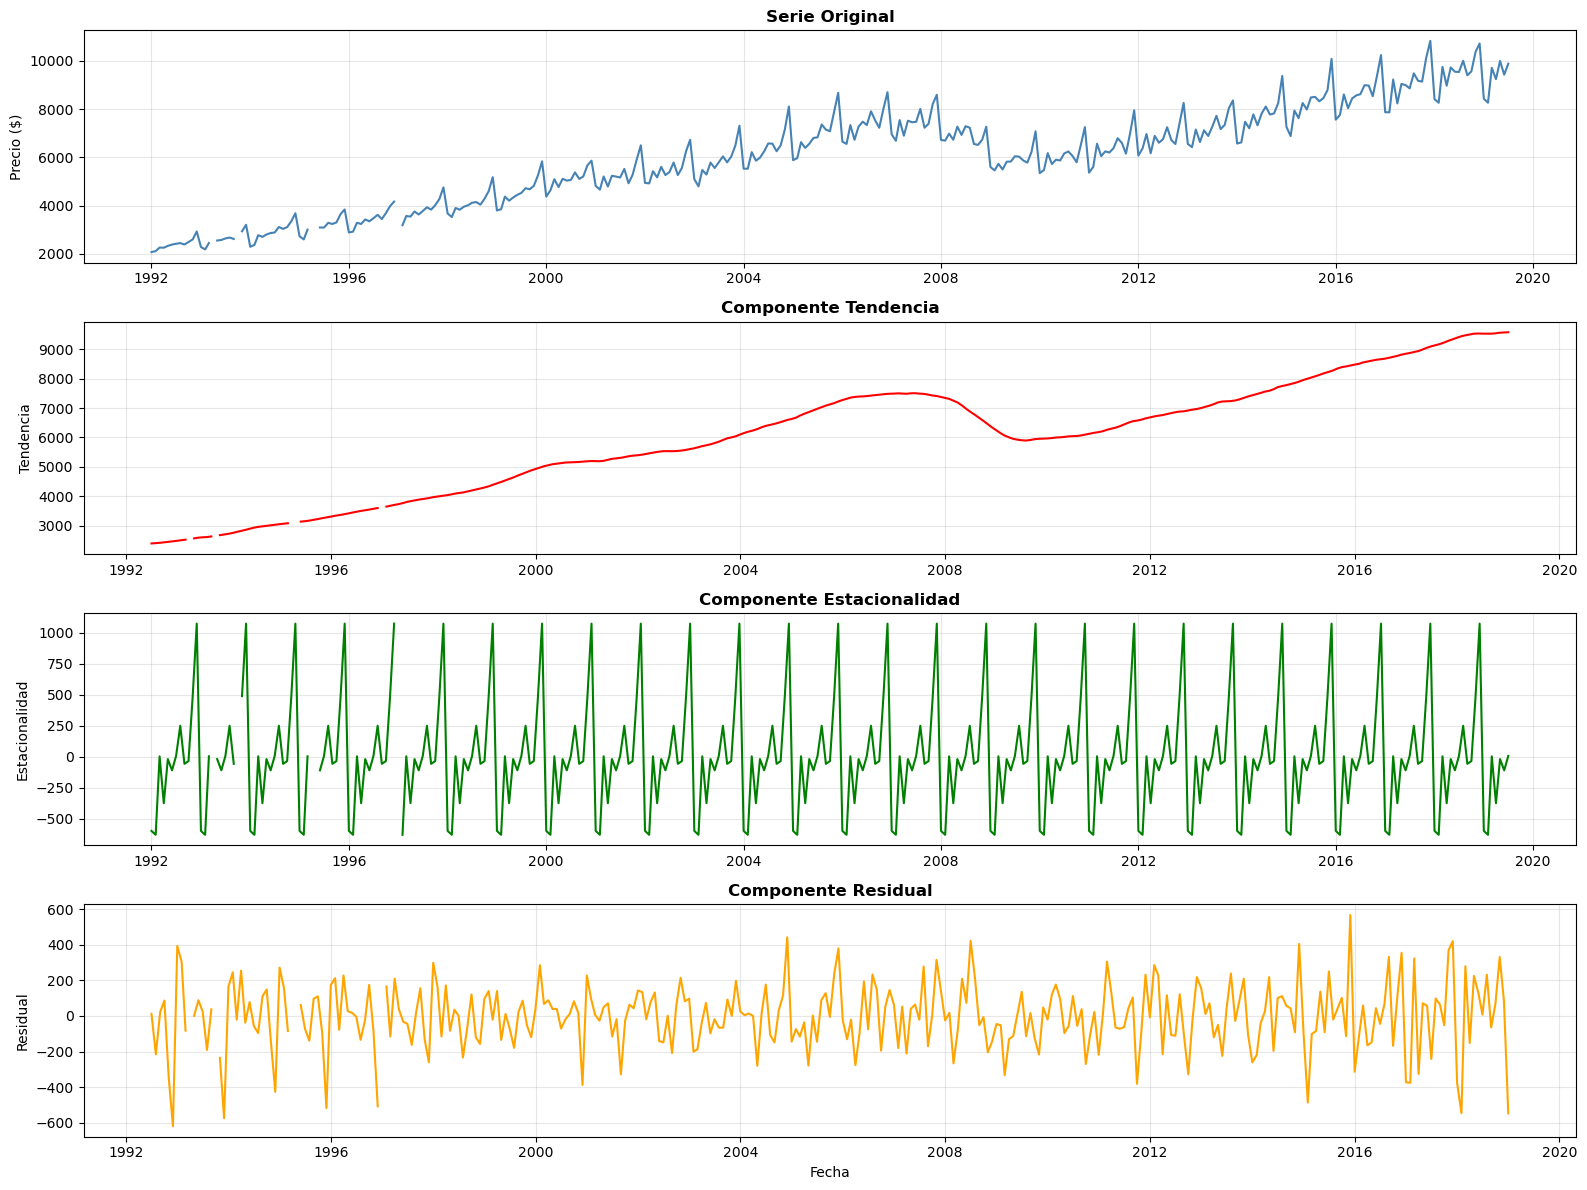

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición de la serie temporal
decomposition = seasonal_decompose(df['furniture_price_adjusted'], model='additive', period=12)

# Extraer componentes
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

# Original
axes[0].plot(df['Month'], df['furniture_price_adjusted'], linewidth=1.5, color='steelblue')
axes[0].set_title('Serie Original', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precio ($)')
axes[0].grid(True, alpha=0.3)

# Tendencia
axes[1].plot(df['Month'], trend, linewidth=1.5, color='red')
axes[1].set_title('Componente Tendencia', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Tendencia')
axes[1].grid(True, alpha=0.3)

# Estacionalidad
axes[2].plot(df['Month'], seasonal, linewidth=1.5, color='green')
axes[2].set_title('Componente Estacionalidad', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Estacionalidad')
axes[2].grid(True, alpha=0.3)

# Residuos
axes[3].plot(df['Month'], residual, linewidth=1.5, color='orange')
axes[3].set_title('Componente Residual', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Fecha')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional

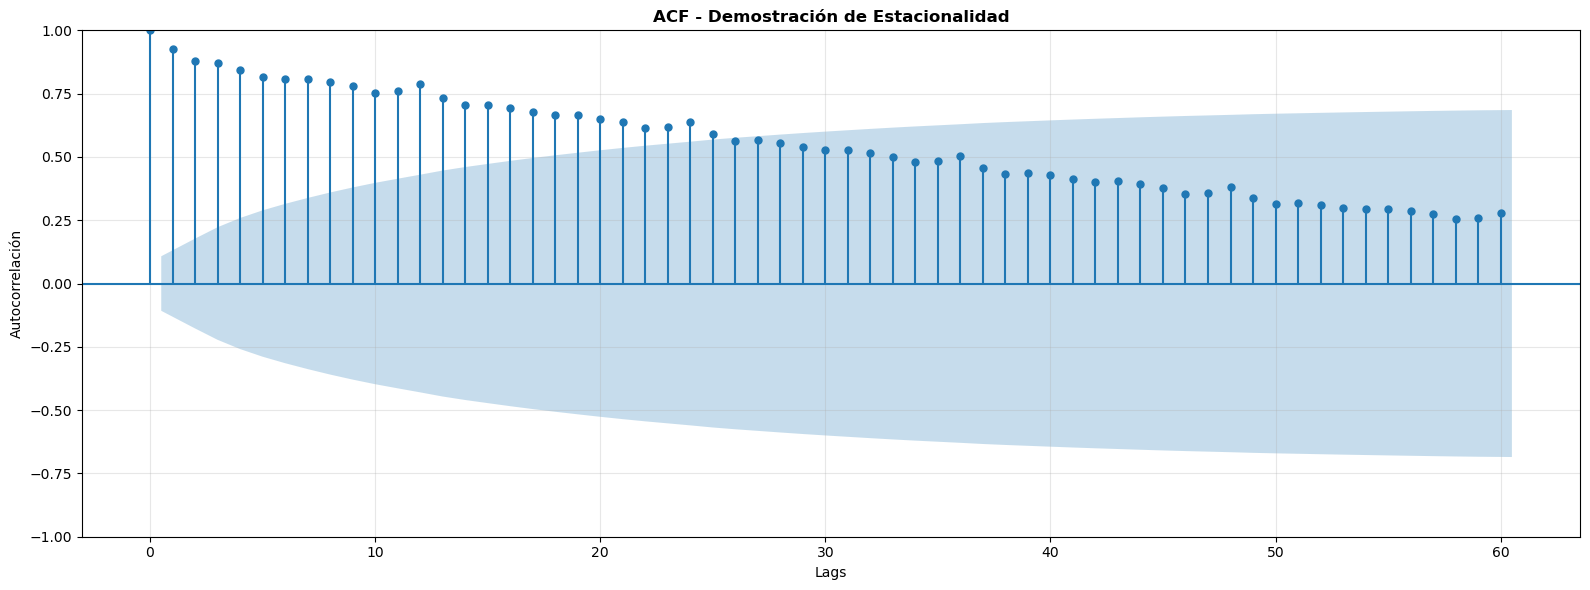

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 1, figsize=(16, 6))

plot_acf(df['furniture_price_adjusted'], lags=60, ax=axes)
axes.set_title('ACF - Demostración de Estacionalidad', fontsize=12, fontweight='bold')
axes.set_xlabel('Lags')
axes.set_ylabel('Autocorrelación')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




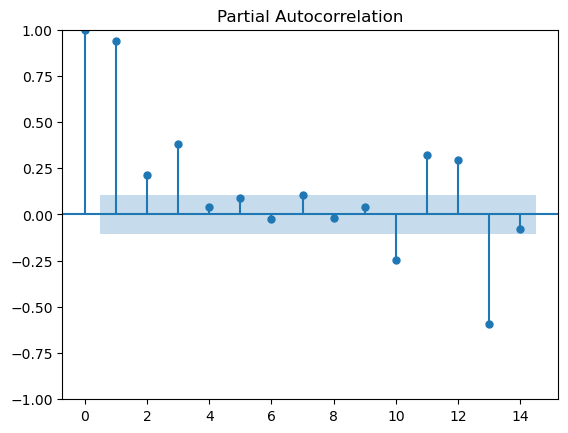

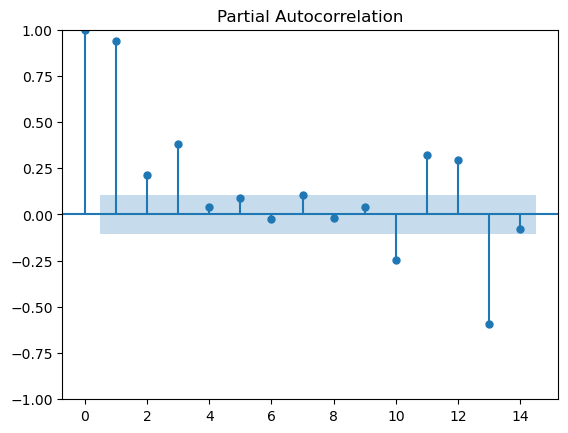

In [36]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df[['furniture_price_adjusted']].values , lags=14)

Hay picos recurrentes cada 12 lags,
indicando que la serie tiene estacionalidad de 12 meses.

## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación.

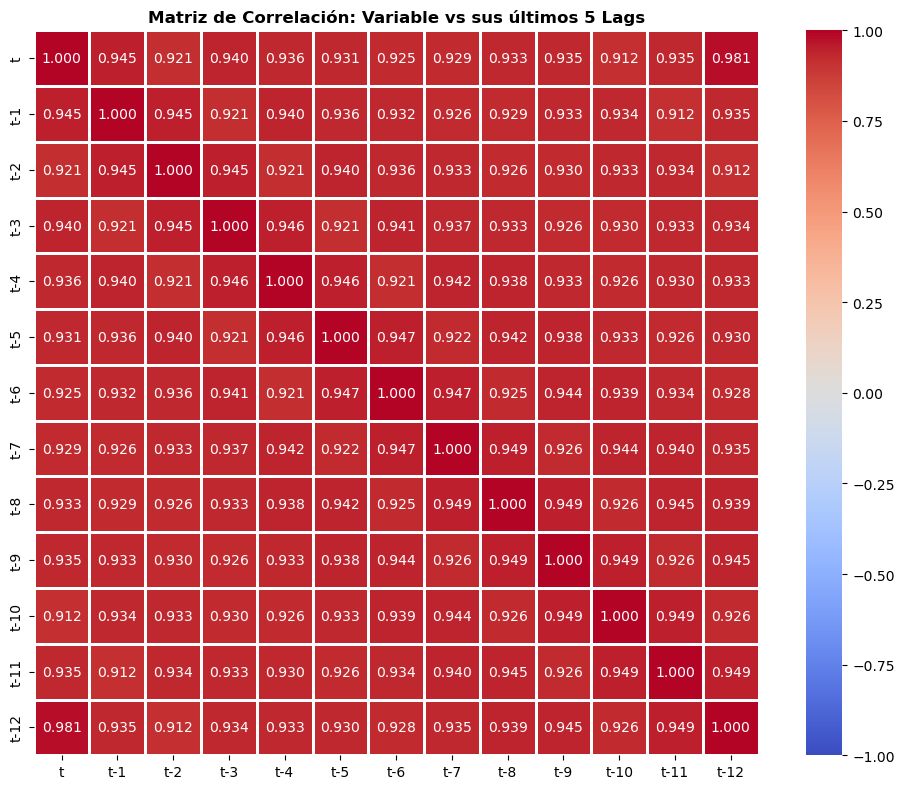

In [37]:
# Crear dataframe con lags
df_lags = pd.DataFrame()
df_lags['t'] = df['furniture_price_adjusted'].values
df_lags['t-1'] = df['furniture_price_adjusted'].shift(1).values
df_lags['t-2'] = df['furniture_price_adjusted'].shift(2).values
df_lags['t-3'] = df['furniture_price_adjusted'].shift(3).values
df_lags['t-4'] = df['furniture_price_adjusted'].shift(4).values
df_lags['t-5'] = df['furniture_price_adjusted'].shift(5).values
df_lags['t-6'] = df['furniture_price_adjusted'].shift(6).values
df_lags['t-7'] = df['furniture_price_adjusted'].shift(7).values
df_lags['t-8'] = df['furniture_price_adjusted'].shift(8).values
df_lags['t-9'] = df['furniture_price_adjusted'].shift(9).values
df_lags['t-10'] = df['furniture_price_adjusted'].shift(10).values
df_lags['t-11'] = df['furniture_price_adjusted'].shift(11).values
df_lags['t-12'] = df['furniture_price_adjusted'].shift(12).values


# Eliminar NaN
df_lags = df_lags.dropna()

# Calcular matriz de correlación
corr_matrix = df_lags.corr()

# Visualizar
fig, axes = plt.subplots(1, 1, figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, ax=axes, vmin=-1, vmax=1)
axes.set_title('Matriz de Correlación: Variable vs sus últimos 5 Lags', 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?

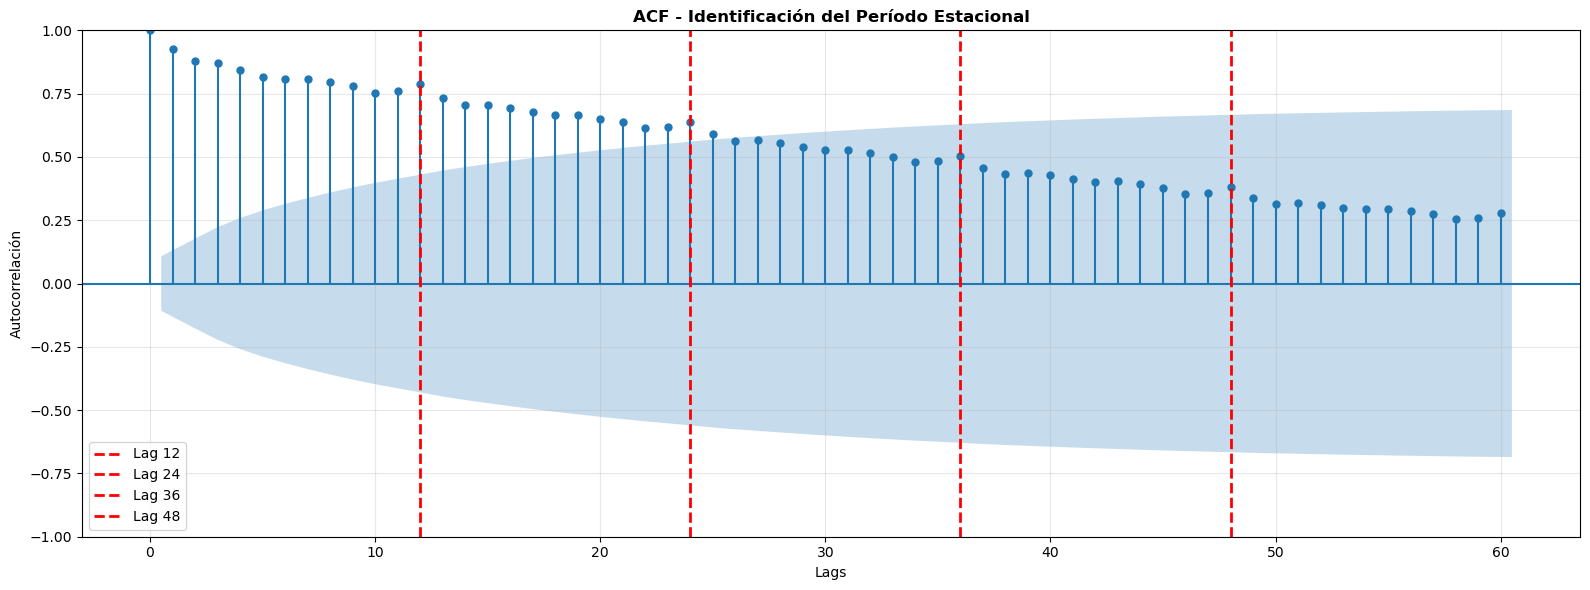

In [12]:
# Usar la gráfica ACF para identificar el período de estacionalidad
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 1, figsize=(16, 6))

plot_acf(df['furniture_price_adjusted'], lags=60, ax=axes)
axes.set_title('ACF - Identificación del Período Estacional', fontsize=12, fontweight='bold')
axes.set_xlabel('Lags')
axes.set_ylabel('Autocorrelación')
axes.axvline(x=12, color='red', linestyle='--', linewidth=2, label='Lag 12')
axes.axvline(x=24, color='red', linestyle='--', linewidth=2, label='Lag 24')
axes.axvline(x=36, color='red', linestyle='--', linewidth=2, label='Lag 36')
axes.axvline(x=48, color='red', linestyle='--', linewidth=2, label='Lag 48')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

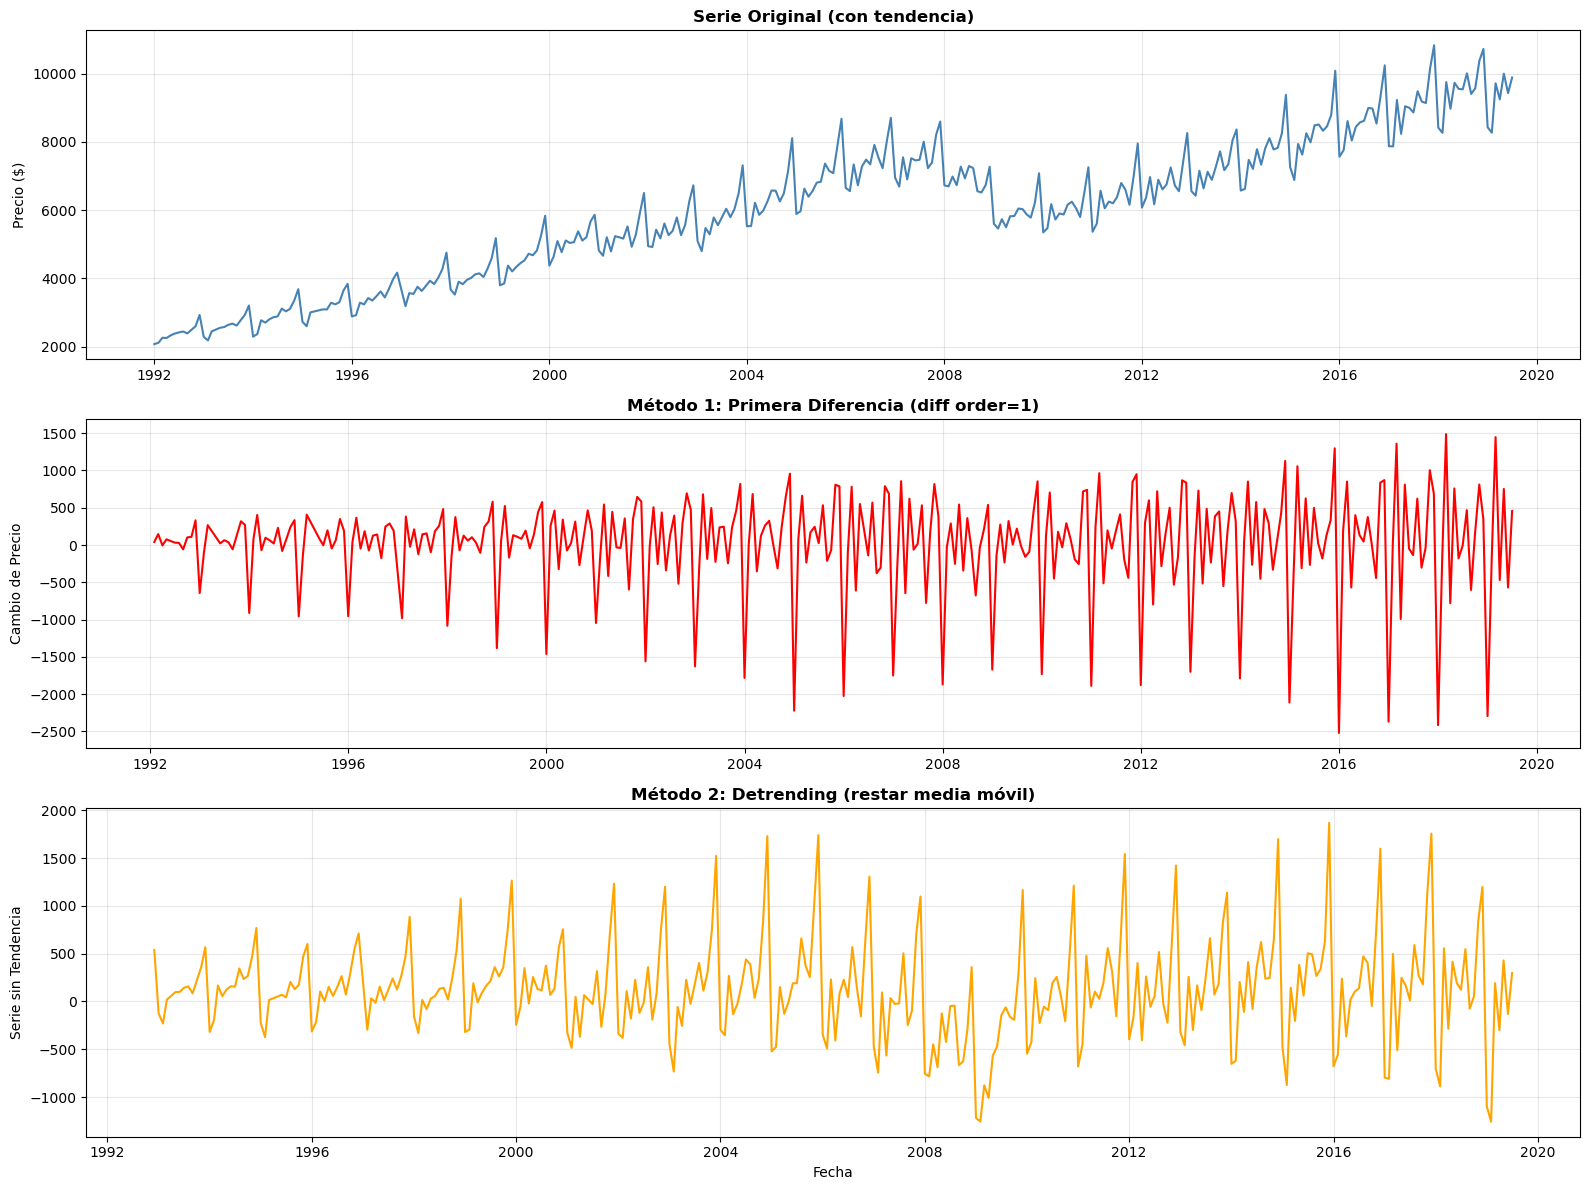

In [ ]:
# MÉTODO 1: DIFERENCIACIÓN (Primera diferencia)
df['diff_1'] = df['furniture_price_adjusted'].diff()

# MÉTODO 2: DETRENDING (Restar media móvil)
df['detrended'] = df['furniture_price_adjusted'] - df['furniture_price_adjusted'].rolling(window=12).mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Original
axes[0].plot(df['Month'], df['furniture_price_adjusted'], linewidth=1.5, color='steelblue')
axes[0].set_title('Serie Original (con tendencia)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Precio ($)')
axes[0].grid(True, alpha=0.3)

# Diferenciación simple
axes[1].plot(df['Month'], df['diff_1'], linewidth=1.5, color='red')
axes[1].set_title('Método 1: Primera Diferencia (diff order=1)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cambio de Precio')
axes[1].grid(True, alpha=0.3)

# Detrending
axes[2].plot(df['Month'], df['detrended'], linewidth=1.5, color='orange')
axes[2].set_title('Método 2: Detrending (restar media móvil)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Serie sin Tendencia')
axes[2].set_xlabel('Fecha')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# hacer también con el seasonal decompose